## Transfer Learning
- Wifi y LTE
- pytorch


In [1]:
import os

# 1. Define la ruta de la carpeta que contiene seg_train, seg_val, seg_test
# ¡DEBES REEMPLAZAR ESTA RUTA CON LA RUTA ABSOLUTA CORRECTA DE TU PC!
#
# La ruta corregida está aquí:
ruta_base_dataset = 'C:/Users/PAUL/Downloads/IA remoto/ENTRENAR MODELO/'

# 2. Lista el contenido de esa carpeta
try:
    contenido = os.listdir(ruta_base_dataset)

    # 3. Imprime los nombres de las carpetas/archivos
    print(f"Contenido de la carpeta '{ruta_base_dataset}':")
    for item in contenido:
        print(item)
except FileNotFoundError:
    print(f"¡ERROR! No se pudo encontrar la ruta:")
    print(f"{ruta_base_dataset}")
    print("Por favor, revisa que la ruta esté escrita exactamente igual que en tu explorador de archivos.")

¡ERROR! No se pudo encontrar la ruta:
C:/Users/PAUL/Downloads/IA remoto/ENTRENAR MODELO/
Por favor, revisa que la ruta esté escrita exactamente igual que en tu explorador de archivos.


In [2]:
#Verifico la capacidad de GPU
!nvidia-smi

Tue Nov  4 11:00:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 37%   42C    P0             41W /  170W |     885MiB /  12288MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
#Librerias a importar
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
import time
import copy
from torch.utils.data import DataLoader, random_split
import os

# ... (el resto de tu código de rutas y carga)

Carga de las imágenes para entrenamiento

La normalizacion de las imágenes utiliza datos de Imagenet [0.485, 0.456, 0.406],                       [0.229, 0.224, 0.225]

Para val se añadio data augmentation, al tener pocas imagenes.

In [11]:



# 1. Definir las rutas correctas para cada conjunto de datos
# --- ¡RUTA CORREGIDA! ---
# (Se usa r"..." para que Windows lea la ruta correctamente)
ruta_train = r'C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_train'
ruta_pred = r'C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test'
ruta_test = r'C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test'

# 2. Definir las transformaciones
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Cargar las imágenes y dividir el dataset
try:
    print(f"Cargando 'train_dataset' desde: {ruta_train}")
    train_dataset = torchvision.datasets.ImageFolder(
        root=ruta_train,
        transform=transform_train
    )

    print(f"Cargando 'test_dataset' desde: {ruta_test}")
    test_dataset = torchvision.datasets.ImageFolder(
        root=ruta_test,
        transform=transform_eval
    )

    # 4. Imprimir para verificar
    print(f"Datos de entrenamiento: {train_dataset}")
    print(f"Datos de prueba: {test_dataset}")


    # 5. Cargar datos de predicción
    print(f"Cargando 'pred_dataset' desde: {ruta_pred}")
    pred_dataset = torchvision.datasets.ImageFolder(
        root=ruta_pred,
        transform=transform_eval 
    )
    print(f"Datos de predicción: {pred_dataset}")


    # 6. Dividir el dataset de entrenamiento para validación
    print("\nDividiendo el dataset de entrenamiento...")
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size

    # Dividir el dataset
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    print(f"Dataset de entrenamiento original: {len(train_dataset)} imágenes")
    print(f"Nuevo subset de entrenamiento: {len(train_subset)} imágenes")
    print(f"Nuevo subset de validación: {len(val_subset)} imágenes")
    print("\n¡Carga de datos exitosa!")

except FileNotFoundError as e:
    print(f"\n--- ¡ERROR! NO SE ENCONTRÓ LA RUTA ---")
    print(f"Error específico: {e}")
except Exception as e:
    print(f"\n--- OTRO ERROR OCURRIÓ ---")
    print(f"Error específico: {e}")

Cargando 'train_dataset' desde: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_train
Cargando 'test_dataset' desde: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test
Datos de entrenamiento: Dataset ImageFolder
    Number of datapoints: 14034
    Root location: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Datos de prueba: Dataset ImageFolder
    Number of datapoints: 3000
    Root location: C:\Users\USUARIO\Downloads\IA remoto\ENTRENAR MODELO\seg_test
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224)

Se prepara los "loader" para train, val y test. Se utilizara un batch_size = 32


In [12]:
import torch
from torch.utils.data import DataLoader

# Definimos los tamaños de batch
batch_size_train = 4
batch_size_test = 4
batch_size_val = 4
learning_rate = 0.001
num_epocas = 4
step_log = 100

# Creamos los DataLoaders usando los SUBSETS
# (Se corrigieron los espacios invisibles en la indentación)
train_loader = DataLoader(dataset=train_subset,
                          batch_size=batch_size_train,
                          shuffle=True)

val_loader = DataLoader(dataset=val_subset,
                        batch_size=batch_size_val,
                        shuffle=False) # No es necesario barajar en validación

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size_test,
                         shuffle=False) # No es necesario barajar en prueba

# Opcional: un loader para tus datos de predicción
pred_loader = DataLoader(dataset=pred_dataset,
                         batch_size=batch_size_test,
                         shuffle=False)

# Arreglamos el NameError. Los nombres de las clases se sacan del dataset original.
class_names = train_dataset.classes
print(f"Clases encontradas: {class_names}")

Clases encontradas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Se visualiza 4 imágenes de un batch tomados de train_loader, se añade los datos de normalizacion para la correcta visualizacion de las imágenes

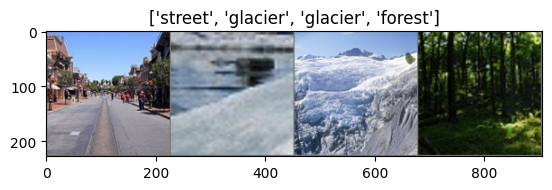

In [13]:
def imshow(inp, title = None):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  plt.imshow(inp)
  
  if title is not None:
    plt.title(title)
  plt.pause(0.001)
  
inputs, classes = next(iter(val_loader))
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

GPU para el enternamiento, verifico que se utilize CUDA
0-> para el primer gpu
1-> para seleccionar el segundo GPU en caso se tuviera

In [14]:
torch.cuda.set_device(0) 
device = ('cuda' if torch.cuda.is_available() else 'cpu')

print("Se entrenara con:", device)

Se entrenara con: cuda


Arquitectura de la red

Función de entrenamiento para train y val

Se añade comentarios tomados de la documentación y foros explicando el proceso y parámetros utilizados

In [15]:
# Celda [17] - REEMPLAZA tu función train_model

# ¡Añadimos train_loader y val_loader como argumentos!
def train_model(model, criterio, optimizer, scheduler, num_epochs, train_loader, val_loader):  
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_acc_train = 0.0
    
    # --- ¡CORRECCIÓN! ---
    # Obtenemos los tamaños de los datasets desde los loaders que pasamos
    train_dataset_size = len(train_loader.dataset)
    val_dataset_size = len(val_loader.dataset)
    
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-' * 25)
    
        # --- Fase de Entrenamiento ---
        model.train()
    
        running_loss = 0.0
        running_corrects = 0.0
    
        # Usamos el train_loader que pasamos como argumento
        for inputs, labels in train_loader: 
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        # --- ¡CORRECCIÓN! ---
        epoch_loss_train = running_loss / train_dataset_size # Usamos el tamaño del subset
        epoch_acc_train = running_corrects.double() / train_dataset_size # Usamos el tamaño del subset
    
        print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss_train, epoch_acc_train))
        if epoch_acc_train > best_acc_train:
              best_acc_train = epoch_acc_train
        
           
        # --- Fase de Validación ---
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
    
        # Usamos el val_loader que pasamos como argumento
        for inputs, labels in val_loader: 
            inputs = inputs.to(device)
            labels = labels.to(device)
        
            with torch.set_grad_enabled(False):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
            
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
        # --- ¡CORRECCIÓN! ---
        epoch_loss_val = running_loss / val_dataset_size # Usamos el tamaño del subset
        epoch_acc_val = running_corrects.double() / val_dataset_size # Usamos el tamaño del subset
                   
        print('Val Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss_val, epoch_acc_val))
        
        # Actualizamos el scheduler DESPUÉS de la validación
        scheduler.step()
                      
        if epoch_acc_val > best_acc:
              best_acc = epoch_acc_val
              best_model_wts = copy.deepcopy(model.state_dict())
              torch.save(best_model_wts, 'resnetxt.pth')
              
    time_elapsed = time.time() - since
    print("####################################################")
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
    print('Best train accucary: {:.4f}'.format(best_acc_train))
    print('Best val accucary: {:.4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

Funcion test

In [16]:
def test_model(model):
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
            
    epoch_loss = running_loss /len(test_dataset)
    epoch_acc = running_corrects.double() / len(test_dataset)
        
    print('Test Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
    return test_model

Visualizar el resultado, se utiliza imagenes en test

In [17]:
def visualize_model(model, num_images):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far +=1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])
                
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
                
        model.train(mode = was_training)


torch.hub.list(github, force_reload=False, skip_validation=False)###Entrenamiento 1

Función de pérdida: CrossEntropyLoss

Optimizador: stochastic gradient descent SGD

In [18]:
import torchvision.models as models
model_ResNetXt = models.resnext50_32x4d(pretrained=True)

e:\conda_envs\paulpro\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\conda_envs\paulpro\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:
# Arquitectura del modelo
model_ResNetXt

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1

In [20]:
num_ft = model_ResNetXt.fc.in_features
model_ResNetXt.fc = nn.Linear(num_ft, 6)

In [21]:
# Modelo a GPU
model_ResNetXt = model_ResNetXt.to(device)

In [22]:
# FUncion de perdidad, optimizador, LR
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_ResNetXt.parameters(), lr = 0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Pruebo el entrenamiento con los datos de test

In [23]:
# Celda [82] - REEMPLAZA esta celda

print("Iniciando el entrenamiento...")

# Llamada CORREGIDA: Pasamos los loaders que creamos en la celda [43]
model_ResNetXt = train_model(model=model_ResNetXt, 
                             criterio=criterion, 
                             optimizer=optimizer, 
                             scheduler=scheduler, 
                             num_epochs=4, 
                             train_loader=train_loader,  # <-- Argumento nuevo
                             val_loader=val_loader)      # <-- Argumento nuevo

print("¡Entrenamiento completado!")

Iniciando el entrenamiento...
Epoch 0/3
-------------------------
Train Loss: 0.8899 Acc: 0.6852
Val Loss: 0.4027 Acc: 0.8657
Epoch 1/3
-------------------------
Train Loss: 0.6350 Acc: 0.7769
Val Loss: 0.3362 Acc: 0.8846
Epoch 2/3
-------------------------
Train Loss: 0.5199 Acc: 0.8190
Val Loss: 0.3605 Acc: 0.8853
Epoch 3/3
-------------------------
Train Loss: 0.4846 Acc: 0.8290
Val Loss: 0.3305 Acc: 0.8821
####################################################
Training complete in 10m 20s
Best train accucary: 0.8290
Best val accucary: 0.8853
¡Entrenamiento completado!


Visualización de resultados en test

In [24]:
model_ResNetXt_test = test_model(model_ResNetXt)

Test Loss: 0.2888 Acc: 0.9087


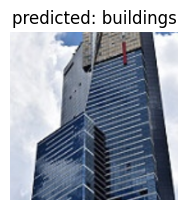

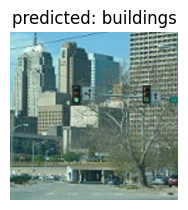

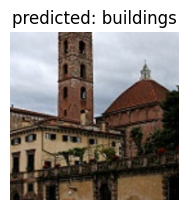

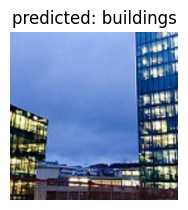

In [25]:
visualize_model(model=model_ResNetXt, num_images = 4)